In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv('data/silver/cleaned_data.csv')
df.head()


,site,name,raw_html
0,Made_in_CA_Grocery_Guide,"Bassili's Best - Frozen chicken lasagna, meat ...","<tr class=""row-2"">\n<td class=""column-1"">Bassi..."
1,Made_in_CA_Grocery_Guide,"BC Hot House Foods - Fresh produce (tomatoes, ...","<tr class=""row-3"">\n<td class=""column-1"">BC Ho..."
2,Made_in_CA_Grocery_Guide,Bergen Farms - Fresh and frozen berries,"<tr class=""row-4"">\n<td class=""column-1"">Berge..."
3,Made_in_CA_Grocery_Guide,"Cedar Phoenicia - Pearl barley, soft wheat, br...","<tr class=""row-5"">\n<td class=""column-1"">Cedar..."
4,Made_in_CA_Grocery_Guide,"Cheemo Perogies - Cheddar cheese, bacon, three...","<tr class=""row-6"">\n<td class=""column-1"">Cheem..."


In [2]:
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   site      60 non-null     str  
 1   name      60 non-null     str  
 2   raw_html  60 non-null     str  
dtypes: str(3)
memory usage: 1.5 KB
site        0
name        0
raw_html    0
dtype: int64


In [3]:
def extract_province(html):
    provinces = ['Ontario', 'Quebec', 'British Columbia', 'Alberta', 'Manitoba', 'Saskatchewan', 'Nova Scotia', 'New Brunswick', 'Newfoundland']
    for prov in provinces:
        if prov.lower() in html.lower():
            return prov
    return 'Unknown'

df['province'] = df['raw_html'].apply(extract_province)
df['province'].value_counts()

province
Unknown             21
Ontario             21
British Columbia     5
Quebec               5
Alberta              4
New Brunswick        1
Manitoba             1
Newfoundland         1
Nova Scotia          1
Name: count, dtype: int64

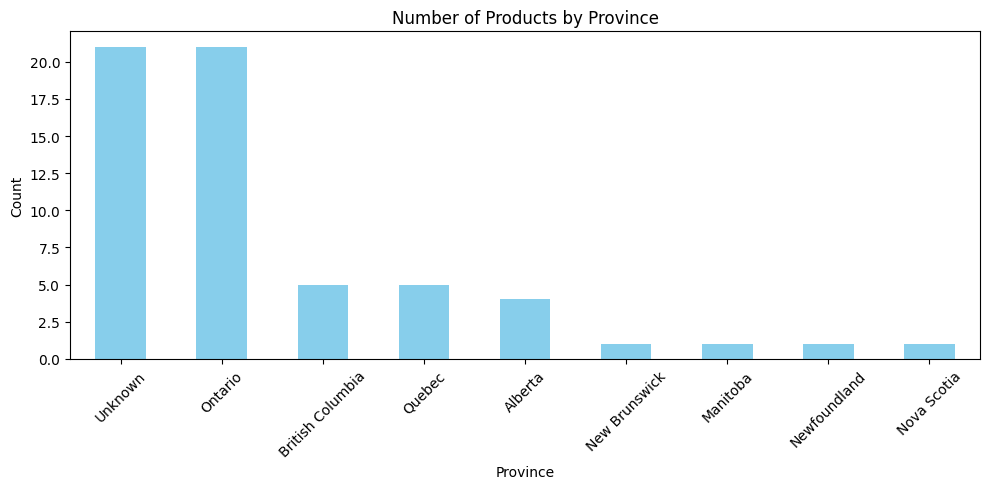

In [4]:
prov_counts = df['province'].value_counts()
plt.figure(figsize=(10,5))
prov_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Products by Province')
plt.xlabel('Province')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

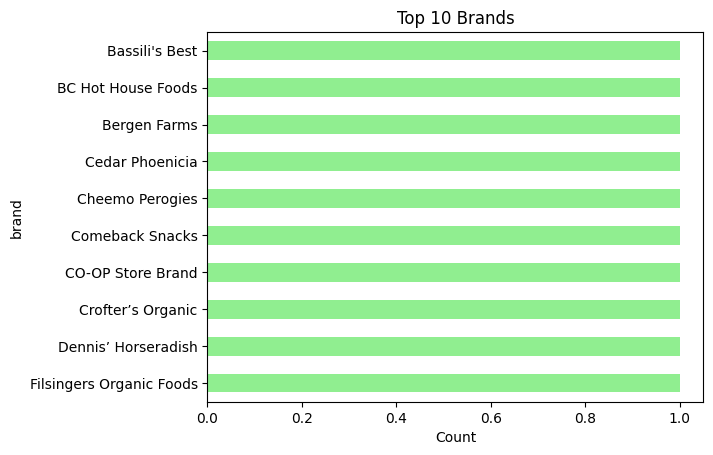

In [5]:
df['brand'] = df['name'].apply(lambda x: x.split(' - ')[0] if ' - ' in x else x[:30])
top_brands = df['brand'].value_counts().head(10)
top_brands.plot(kind='barh', color='lightgreen')
plt.title('Top 10 Brands')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()